# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

4422102/4422102 [==============================] - 0s 0us/step


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical

# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')




X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


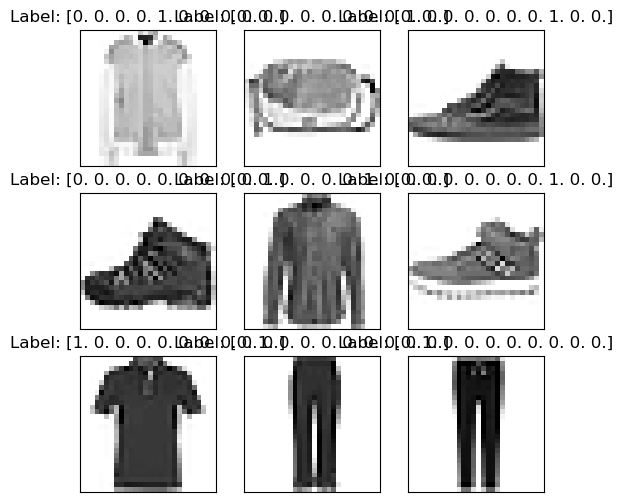

In [18]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y_train[random_indices[i]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

 + The image quality in the Fashion MNIST dataset is not very good. Each image is black and white and only 28 by 28 pixels in size, which is quite small. Because of this, some items look very similar. For example, a shirt and a T-shirt can be hard to tell apart. This low detail makes it harder for the model to learn the differences between certain classes, and it may lead to wrong predictions for similar-looking clothes.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [27]:
from keras.models import Sequential
from keras.layers import Dense, Flatten


# Create a simple linear regression model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
# You can use `model.add(<layer>)` to add layers to the model
model.add(Dense(10))

# Compile the model using `model.compile()`
model.compile( optimizer='adam', # Optimizer
               loss='categorical_crossentropy', # Loss function
               metrics=['accuracy'] # Metrics to evaluate the model
            )


# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 [==============================] - 9s 4ms/step - loss: 10.3606 - accuracy: 0.2533 - val_loss: 9.8430 - val_accuracy: 0.2944
Epoch 2/5
1500/1500 [==============================] - 7s 5ms/step - loss: 10.0267 - accuracy: 0.2263 - val_loss: 12.4391 - val_accuracy: 0.2016
Epoch 3/5
1500/1500 [==============================] - 6s 4ms/step - loss: 10.3460 - accuracy: 0.1920 - val_loss: 10.9875 - val_accuracy: 0.1693
Epoch 4/5
1500/1500 [==============================] - 5s 4ms/step - loss: 9.9927 - accuracy: 0.1595 - val_loss: 10.5344 - val_accuracy: 0.1564
Epoch 5/5
313/313 [==============================] - 1s 3ms/step - loss: 8.2372 - accuracy: 0.2235
Loss:     8.24
Accuracy: 22.35%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

+ The performance of the baseline linear regression model is quite low (loss: 8.24, accuracy: 22.35%), which is expected. The main reason is that the model is too simple. It doesn't have any hidden layers or non-linear activation functions. Without these, the model is limited to learning only linear relationships between pixel values and output classes. However, image classification is a complex, non-linear problem, and the model needs non-linear activation functions and deeper layers to learn patterns such as shapes, edges, and textures. As a result, this simple linear model cannot capture the complexity of the data, leading to poor performance.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

# Convolutional layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Fully connected layer
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))

# 🏷 Output layer for classification
model.add(Dense(units=10, activation='softmax'))


# Compiling the model
model.compile( optimizer='adam', # Optimizer
               loss='categorical_crossentropy', # Loss function
               metrics=['accuracy'] # Metrics to evaluate the model
            )

# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 [==============================] - 47s 30ms/step - loss: 0.3957 - accuracy: 0.8596 - val_loss: 0.2969 - val_accuracy: 0.8914
Epoch 2/5
1500/1500 [==============================] - 49s 33ms/step - loss: 0.2560 - accuracy: 0.9067 - val_loss: 0.2784 - val_accuracy: 0.8997
Epoch 3/5
1500/1500 [==============================] - 48s 32ms/step - loss: 0.2000 - accuracy: 0.9263 - val_loss: 0.2732 - val_accuracy: 0.9016
Epoch 4/5
1500/1500 [==============================] - 43s 29ms/step - loss: 0.1558 - accuracy: 0.9419 - val_loss: 0.2703 - val_accuracy: 0.9086
Epoch 5/5
313/313 [==============================] - 3s 8ms/step - loss: 0.3331 - accuracy: 0.8931
Loss:     0.33
Accuracy: 89.31%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, the CNN model performed significantly better than the baseline model. While the baseline model achieved an accuracy of only 22.35%, the CNN reached 89.31%, resulting in a performance improvement of approximately 66.96 percentage points. This improvement is mainly due to the use of convolutional layers, which are well-suited for image data as they can detect spatial features like edges, textures, and patterns. In contrast, the baseline linear model treated all pixels independently and could only learn simple patterns, leading to poor accuracy. So, by using a convolutional layer, the CNN learned more useful details from the images and made much better predictions.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters

exp_results = {}

for f in (32, 64, 128):
# Create a simple CNN model
    model = Sequential()

# Convolutional layer
    model.add(Conv2D(filters= f, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Fully connected layer
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))

# 🏷 Output layer for classification
    model.add(Dense(units=10, activation='softmax'))


# Compiling the model
    model.compile( optimizer='adam', # Optimizer
            loss='categorical_crossentropy', # Loss function
            metrics=['accuracy'] # Metrics to evaluate the model
        )

# Train the model
    model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
    )

# Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)

    exp_results[f'FilterAccuracy_{f}'] = f'{accuracy * 100:.2f}%'

Epoch 1/5
1500/1500 [==============================] - 47s 30ms/step - loss: 0.3891 - accuracy: 0.8600 - val_loss: 0.3038 - val_accuracy: 0.8881
Epoch 2/5
1500/1500 [==============================] - 44s 30ms/step - loss: 0.2519 - accuracy: 0.9085 - val_loss: 0.2751 - val_accuracy: 0.8989
Epoch 3/5
1500/1500 [==============================] - 43s 28ms/step - loss: 0.1954 - accuracy: 0.9276 - val_loss: 0.2660 - val_accuracy: 0.9058
Epoch 4/5
1500/1500 [==============================] - 41s 27ms/step - loss: 0.1487 - accuracy: 0.9447 - val_loss: 0.2851 - val_accuracy: 0.9069
Epoch 5/5
313/313 [==============================] - 3s 8ms/step - loss: 0.3321 - accuracy: 0.8993
Epoch 1/5
1500/1500 [==============================] - 100s 65ms/step - loss: 0.3907 - accuracy: 0.8615 - val_loss: 0.3081 - val_accuracy: 0.8876
Epoch 2/5
1500/1500 [==============================] - 83s 55ms/step - loss: 0.2496 - accuracy: 0.9088 - val_loss: 0.2655 - val_accuracy: 0.9043
Epoch 3/5
1500/1500 [=========

In [ ]:
exp_results

{'FilterAccuracy_32': '89.93%',
 'FilterAccuracy_64': '90.21%',
 'FilterAccuracy_128': '89.92%'}

In [35]:
# B. Test presence or absence of regularization
# L2 regularization technique

from keras import regularizers

reg_results = {}

for k_name, k_value in [('None', None), ('L2_0.001', regularizers.l2(0.001))]:
# Create a simple CNN model
    model = Sequential()

# Convolutional layer
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1),
                      kernel_regularizer=k_value))

# Fully connected layer
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu', kernel_regularizer=k_value))

# 🏷 Output layer for classification
    model.add(Dense(units=10, activation='softmax'))


# Compiling the model
    model.compile( optimizer='adam', # Optimizer
               loss='categorical_crossentropy', # Loss function
               metrics=['accuracy'] # Metrics to evaluate the model
            )

# Train the model
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )

# Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    reg_results[k_name] = f'{accuracy * 100:.2f}%'

   


Epoch 1/5
1500/1500 [==============================] - 39s 26ms/step - loss: 0.3958 - accuracy: 0.8581 - val_loss: 0.3386 - val_accuracy: 0.8760
Epoch 2/5
1500/1500 [==============================] - 36s 24ms/step - loss: 0.2563 - accuracy: 0.9072 - val_loss: 0.2704 - val_accuracy: 0.9009
Epoch 3/5
1500/1500 [==============================] - 36s 24ms/step - loss: 0.1964 - accuracy: 0.9261 - val_loss: 0.2803 - val_accuracy: 0.8997
Epoch 4/5
1500/1500 [==============================] - 41s 27ms/step - loss: 0.1553 - accuracy: 0.9434 - val_loss: 0.2962 - val_accuracy: 0.9029
Epoch 5/5
313/313 [==============================] - 2s 6ms/step - loss: 0.3133 - accuracy: 0.9041
Epoch 1/5
1500/1500 [==============================] - 49s 32ms/step - loss: 0.6257 - accuracy: 0.8315 - val_loss: 0.5714 - val_accuracy: 0.8492
Epoch 2/5
1500/1500 [==============================] - 47s 31ms/step - loss: 0.5237 - accuracy: 0.8619 - val_loss: 0.5083 - val_accuracy: 0.8644
Epoch 3/5
1500/1500 [==========

In [36]:
reg_results

{'None': '90.41%', 'L2_0.001': '87.35%'}

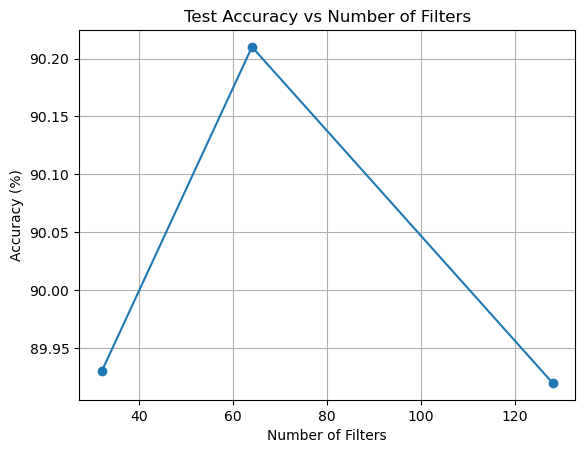

In [34]:
import matplotlib.pyplot as plt

filters = [32, 64, 128]
accuracies = [89.93, 90.21, 89.92]

plt.plot(filters, accuracies, marker='o')
plt.title("Test Accuracy vs Number of Filters")
plt.xlabel("Number of Filters")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

+ The experiment and the plot shows that in the CNN model increasing the number of filters in the convolutional layer, while keeping all other parameters same, slightly improved model performance up to a point. With 32 filters, the test accuracy was 89.93%, which increased to 90.21% with 64 filters. However, increasing to 128 filters did not lead to further improvement, with accuracy slightly dropping to 89.92%. This suggests that while more filters can help the model learn better features, too many may lead to overfitting. In this case, 64 filters provided the best performance. 

+ The model without L2 regularization gave a higher accuracy (90.41%) compared to the one with L2 (87.35%), but this doesn’t mean L2 is bad. L2 regularization is mainly used to prevent overfitting by keeping the model’s weights small and simple. In this case, the model may not have been overfitting, so regularization wasn’t necessary. Also, the regularization strength (0.001) might have been too high, which made the model too simple and reduced its learning ability.

+ As a result of these experiments, best results, the model should be trained with 64 filters (hyperparameter) and no regularization.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [37]:
# Create a simple CNN model
model = Sequential()

# Convolutional layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Fully connected layer
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))

# 🏷 Output layer for classification
model.add(Dense(units=10, activation='softmax'))


# Compiling the model
model.compile( optimizer='adam', # Optimizer
               loss='categorical_crossentropy', # Loss function
               metrics=['accuracy'] # Metrics to evaluate the model
            )

# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 [==============================] - 75s 49ms/step - loss: 0.3850 - accuracy: 0.8628 - val_loss: 0.3045 - val_accuracy: 0.8888
Epoch 2/5
1500/1500 [==============================] - 71s 48ms/step - loss: 0.2481 - accuracy: 0.9094 - val_loss: 0.3063 - val_accuracy: 0.8910
Epoch 3/5
1500/1500 [==============================] - 68s 45ms/step - loss: 0.1895 - accuracy: 0.9292 - val_loss: 0.2863 - val_accuracy: 0.9016
Epoch 4/5
1500/1500 [==============================] - 71s 47ms/step - loss: 0.1444 - accuracy: 0.9464 - val_loss: 0.2953 - val_accuracy: 0.8998
Epoch 5/5
313/313 [==============================] - 4s 11ms/step - loss: 0.3292 - accuracy: 0.9026
Loss:     0.33
Accuracy: 90.26%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

+ The final model, which used 64 filters and no regularization, performed better on the test set than both the baseline model and the CNN model with fewer filters or regularization. The baseline model was too simple to capture complex patterns in the images, which is why adding a convolutional layer and an activation function like ReLU helped the model learn more effectively. Increasing the number of filters from 32 to 64 also improved performance because it allowed the model to learn more features and finer details from the images. This helped the model better understand the input data and make more accurate .

+ To improve the model’s performance, I can tune several parameters. These include the learning rate (which controls how quickly the model learns), the kernel size (which affects how much of the image the model looks at when detecting patterns), the number of filters in the convolutional layer, the number of layers in the network, and the batch size and number of epochs used during training. I can also try using dropout as a regularization technique to prevent overfitting,

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.